<a href="https://colab.research.google.com/github/jorge-luis01800/metodos_numericos_I/blob/main/metodo_de_biseccion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Método de bisección

Por definicion, dada $f\in C[a,b]$\
$p$ es raiz de $f$ si $f(p)=0$\
Para cononer $p$ de toda funcion continua existen distintos metodos.\
En particular aplicaremos el **metodo de biseccion** para aproximar el valor de $p$.





## ¿Cómo funciona?
Por el Teorema de valor intermedio\
Si $f\in C[a,b]$ y $k$ es cualquier numero entre $f(a)$ y $f(b)$\
Entonces $\exists c\in [a,b]$ talque $f(c)=k$\
En particular si nuestra $f$ es continua\
donde ademas $f(a)<0$ y $f(b)>0$\
$\implies f(a)<0<f(b)$\
Si $k=0$, por el teorema\
$\exists p \in [a,b]$ tal que $f(p)=0$

Es decir, para concer $p$ necesitamos:


*   Que $f$ sea continua en un intervalo $[a,b]$
*   Dado el intervalo, se cumpla que $f(a)<0$ y $f(b)>0$ <font color="cyan">**...(*)**</font>

Ahora, para acercanos a $p$\
Sabemos que $p\in [a,b]$, tomemos $p_0=a+\frac{(b-a)}{2}$, en efecto:\
$|p-p_0| \leq |p-a|$ o $|p-p_0| \leq |b-p|$\
Por lo que $p_0$ es la mejor aproximacion (pues es es quien mas se acerca)\
Donde si $f(p_0)=0$ (en el mejor de los casos) termina nuestra busqueda,\
pero en caso contrario entonces necesariamente $f(p_0)>0$ o $f(p_0)<0$
luego, dado $p_0$ tenemos que nuestro intervalo original se a dividido en 2 partes y tenemos la capacidad de determinar el lado donde se encuentra $p$, pues si $f(p_0)>0$ y sabemos que $f(a)<0$\
Nuevamente por el Teorema de valor intermedio\
$\exists p \in [a,p_0]$ tal que $f(p)=0$\
Analogamemte si $f(p_0)<0$ y sabemos que $f(b)>0$\
Por el Teorema de valor intermedio\
$\exists p \in [p_0,b]$ tal que $f(p)=0$\
Por lo que determinando la ubicacion de $p$ segun el punto medio, de manera iterativa nos podemos acercar demaciado a $p$






Traemos algunas bibloitecas de funciones y constantes:

In [52]:
from math import *
import numpy as np
import matplotlib. pyplot as plt

Definimos nuestra funcion <font color="cyan">**continua**</font>

In [45]:
#Del ejemplo 1 de la página 38 de Burden
def f(x):
  return x**3 + 4*x**2 -10.0

Luego, definimos los valores importantes para los cuales el programa va a funcionar

In [46]:
#Valores para el intervalo [a,b]
a=1
b=2
#Valores paraticulares
TOL=0.000001 #Margen de precision
N_0=10000     #Cantidad de iteaciones perimitidas

Una pequeña comprovacion de <font color="cyan">**(*)**</font> y de los valores particulares\
En lo que sigue del programa, trataremos la distincion de signo como:\
$f(a)f(b)<0$ (signos opuestos)\
$f(a)f(b)>0$ (mismos signos)

In [47]:
while b<a or f(a)*f(b)> 0 or TOL<0 or N_0<0:
  if f(a)*f(b)>0:
    print("Los valores de a y b no cumplen f(a)f(b)<0 ")
    a=float(input("Ingrese el valor de a: "))
    b=float(input("Ingrese el valor de b: "))
  if TOL<0:
    TOL=float(input("Ingrese una tolerancia positiva: "))
  if N_0<0:
    N_0=int(input("Ingrese una cantidad de iteraciones positivas: "))

Finalmente, desarrollamos el algoritmo:

In [48]:

#Inciamos el conteo de iteraciones en 1, y evaluamos nuestro primer valor "a"
i=1
FA=f(a)

#Imprimimos la parte inicial de la tabla
print("# iter\t\t a \t\t f(a) \t\t b \t\t f(b) \t\t m \t\t f(m) \t\t error")
print("{0} \t\t {1:6.6f} \t {2:6.6f} \t {3:6.6f} \t {4:6.6f} \t {5:6.6f} \t {6:6.6f} \t {7:6.6f}".format(i-1, a, f(a), b, f(b), a+(b-a)/2, f(a+(b-a)/2), (b-a)/2))

#Iniciamos un ciclo que finalice de acuerdo a la cantidad de iteraciones perimitida
while i <= N_0:
  p=a+(b-a)/2                        #Dado el punto medio p entre [a,b]
  FP=f(p)                            #Podemos conocer f(p)
  if FP==0 or (b-a)/2 <TOL:          #Analizamos la situacion segun lo calculado y p (terminamos o seguimos)
    raiz=p
    print("")
    print(f"La raiz aproximada de f es: {raiz}")
    break                            #Llegamos al mejor caso y terminamos el ciclo
  else:
    i=i+1                            #Avanzamos una interacion mas de la permitida
    if FA*FP>0:                      #Analizamos la distincion de signo
      a=p                            #Al ser de signos iguales, el teorema solo se cumple para el lado derecho
      FA=FP                          #Corregimos el valor para la siguiente comprovacion
    else:
      b=p                            #Al ser de signos distintos, el teorema se cumple para el lado izquierdo
    print("{0} \t\t {1:6.6f} \t {2:6.6f} \t {3:6.6f} \t {4:6.6f} \t {5:6.6f} \t {6:6.6f} \t {7:6.6f}".format(i-1, a, FA, b, f(b), p, FP, (b-a)/2))


else:                                #En caso de jamas llegar a p o seguir con un margen nada cercano, el metodo fallo
  print(f"El metodo fracaso despues de {N_0} iteraciones")



# iter		 a 		 f(a) 		 b 		 f(b) 		 m 		 f(m) 		 error
0 		 1.000000 	 -5.000000 	 2.000000 	 14.000000 	 1.500000 	 2.375000 	 0.500000
1 		 1.000000 	 -5.000000 	 1.500000 	 2.375000 	 1.500000 	 2.375000 	 0.250000
2 		 1.250000 	 -1.796875 	 1.500000 	 2.375000 	 1.250000 	 -1.796875 	 0.125000
3 		 1.250000 	 -1.796875 	 1.375000 	 0.162109 	 1.375000 	 0.162109 	 0.062500
4 		 1.312500 	 -0.848389 	 1.375000 	 0.162109 	 1.312500 	 -0.848389 	 0.031250
5 		 1.343750 	 -0.350983 	 1.375000 	 0.162109 	 1.343750 	 -0.350983 	 0.015625
6 		 1.359375 	 -0.096409 	 1.375000 	 0.162109 	 1.359375 	 -0.096409 	 0.007812
7 		 1.359375 	 -0.096409 	 1.367188 	 0.032356 	 1.367188 	 0.032356 	 0.003906
8 		 1.363281 	 -0.032150 	 1.367188 	 0.032356 	 1.363281 	 -0.032150 	 0.001953
9 		 1.363281 	 -0.032150 	 1.365234 	 0.000072 	 1.365234 	 0.000072 	 0.000977
10 		 1.364258 	 -0.016047 	 1.365234 	 0.000072 	 1.364258 	 -0.016047 	 0.000488
11 		 1.364746 	 -0.007989 	 1.365234 	 0.00007

Veamos la funcion de forma grafica y visualmente comprovemos que en efecto, llegamos a una aproximacion muy cerca de $p$

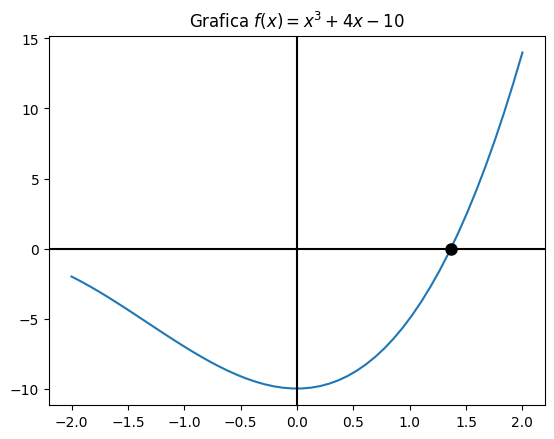

In [63]:
x=np.linspace(-2,2,50) #Generamos 50 particiones de -2 a 2
plt.plot(x,f(x)) #Dibujamos la funcion
plt.title("Grafica $f(x)=x^3+4x-10$") #Nombramos la grafica
plt.axhline(0, color='black') #Dibujamos el eje y
plt.axvline(0, color='black') #Dibujamos el eje x
plt.plot(raiz, 0, 'o', color='black', markersize=8) #Dibujamos el punto
